# Task 1 — Speech Emotion Classification on TESS

**Dataset:** Toronto Emotional Speech Set (TESS) — 2 800 audio recordings, 2 female actors (OAF, YAF) speaking 200 target words each in 7 emotional tones.

**Goal:** Compare three sequence models — **SimpleRNN, LSTM, GRU** — on the same MFCC feature representation and decide which one generalises best.

**Workflow** (matches the rubric):
1. Dataset understanding — shape, classes, missing data, EDA
2. Preprocessing — MFCC extraction, padding, label encoding, train/val/test split
3. Model training & evaluation — RNN / LSTM / GRU with **Dropout + Early Stopping**
4. Comparative analysis — accuracy / precision / recall / F1, confusion matrices, **ROC-AUC** (one-vs-rest)
5. Discussion of results

## 1. Dataset Understanding

In [1]:
import os, glob, warnings, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('librosa   :', librosa.__version__)
print('GPU       :', tf.config.list_physical_devices('GPU'))

I0000 00:00:1778757294.094671   37534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757294.095104   37534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778757294.131561   37534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
librosa   : 0.11.0
GPU       : []


I0000 00:00:1778757295.051617   37534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757295.051888   37534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1778757295.175191   37534 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# Path to the TESS root folder (14 sub-folders: OAF_<emotion>, YAF_<emotion>)
DATA_DIR = Path('/home/student/Downloads/archive/TESS Toronto emotional speech set data')
assert DATA_DIR.exists(), f'TESS folder not found at {DATA_DIR}'

records = []
for wav in DATA_DIR.rglob('*.wav'):
    # filename format: <ACTOR>_<word>_<emotion>.wav  e.g. OAF_back_angry.wav
    parts = wav.stem.split('_')
    actor   = parts[0]                       # OAF or YAF
    emotion = '_'.join(parts[2:]).lower()    # handle 'pleasant_surprise(d)'
    # normalise the few label spelling variants
    emotion = emotion.replace('pleasant_surprised', 'pleasant_surprise')
    emotion = emotion.replace('ps', 'pleasant_surprise') if emotion == 'ps' else emotion
    records.append({'path': str(wav), 'actor': actor, 'emotion': emotion})

df = pd.DataFrame(records)
print('Total files :', len(df))
print('Actors      :', df.actor.unique())
print('Emotions    :', sorted(df.emotion.unique()))
print('Missing     :', df.isna().sum().sum())
df.head()

Total files : 2800
Actors      : <StringArray>
['YAF', 'OAF', 'OA']
Length: 3, dtype: str
Emotions    : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'pleasant_surprise', 'sad']
Missing     : 0


,path,actor,emotion
0,/home/student/Downloads/archive/TESS Toronto e...,YAF,neutral
1,/home/student/Downloads/archive/TESS Toronto e...,YAF,neutral
2,/home/student/Downloads/archive/TESS Toronto e...,YAF,neutral
3,/home/student/Downloads/archive/TESS Toronto e...,YAF,neutral
4,/home/student/Downloads/archive/TESS Toronto e...,YAF,neutral


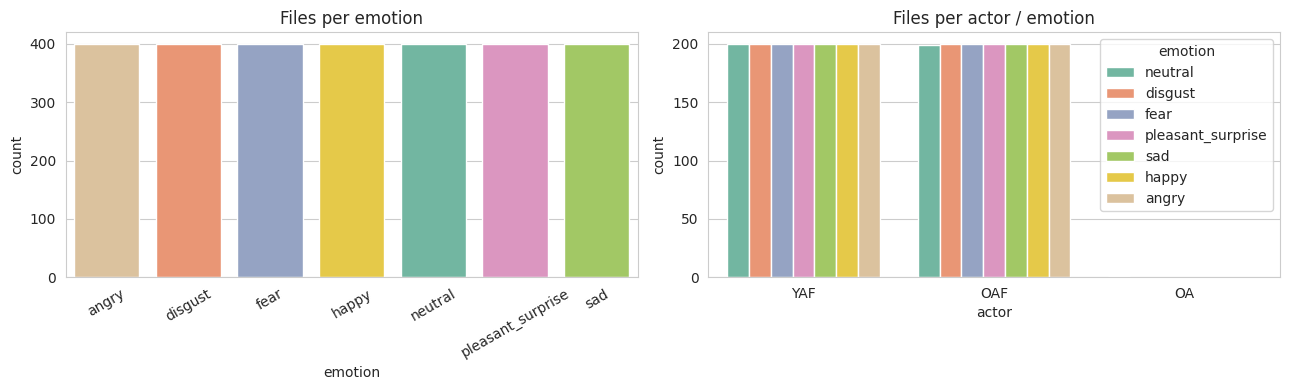

In [3]:
# Class distribution — TESS is perfectly balanced (200 files / actor / emotion)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='emotion', order=sorted(df.emotion.unique()),
              hue='emotion', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title('Files per emotion'); ax[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='actor', hue='emotion', palette='Set2', ax=ax[1])
ax[1].set_title('Files per actor / emotion')
plt.tight_layout(); plt.show()

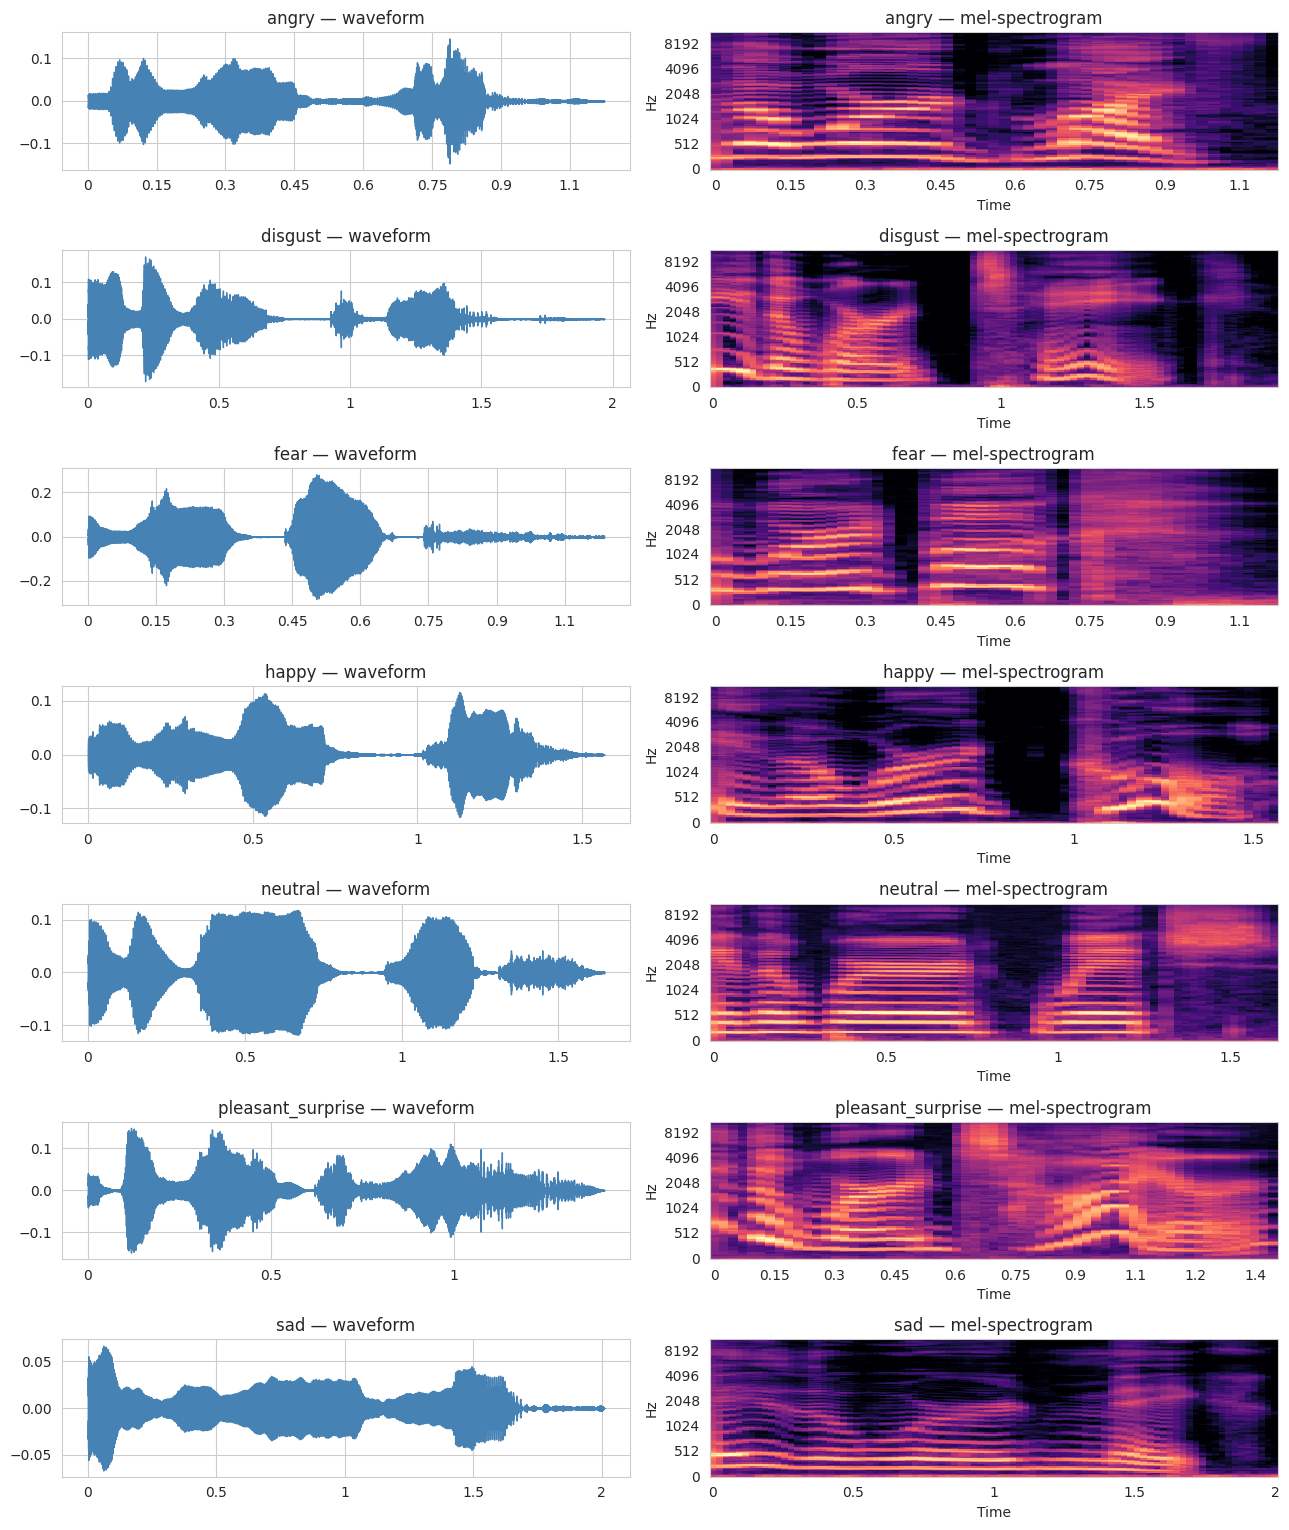

In [4]:
# Visualise one waveform + mel-spectrogram per emotion to understand what the
# network will see.  Different emotions have visibly different energy profiles.
emotions = sorted(df.emotion.unique())
fig, axes = plt.subplots(len(emotions), 2, figsize=(13, 2.2*len(emotions)))

for i, emo in enumerate(emotions):
    sample = df[df.emotion == emo].iloc[0].path
    y, sr  = librosa.load(sample, duration=2.5, offset=0.5)
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{emo} — waveform'); axes[i, 0].set_xlabel('')

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                              sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'{emo} — mel-spectrogram')

plt.tight_layout(); plt.show()

## 2. Preprocessing — MFCC feature extraction

We turn each clip into a fixed-length **(time-step × MFCC)** matrix, exactly the
shape an RNN/LSTM/GRU expects:

* `n_mfcc = 40`  Mel-frequency cepstral coefficients per frame
* `duration = 3 s` (TESS clips are ~2 s on average; 3 s is a safe upper bound)
* hop length 512 → ~130 time steps per clip
* zero-pad / truncate so every sample has identical length
* per-feature standard-scaling (zero mean, unit variance) computed on the **training set only**

In [5]:
SR        = 22050
DURATION  = 3.0           # seconds
N_MFCC    = 40
HOP       = 512
MAX_LEN   = int(np.ceil(SR * DURATION / HOP))   # ~130 frames

def extract_mfcc(path: str) -> np.ndarray:
    """Return a (MAX_LEN, N_MFCC) matrix for one wav file."""
    y, _ = librosa.load(path, sr=SR, duration=DURATION)
    if len(y) < SR * DURATION:
        y = np.pad(y, (0, int(SR * DURATION) - len(y)))
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC, hop_length=HOP).T   # (T, n_mfcc)
    if mfcc.shape[0] < MAX_LEN:
        mfcc = np.pad(mfcc, ((0, MAX_LEN - mfcc.shape[0]), (0, 0)))
    else:
        mfcc = mfcc[:MAX_LEN]
    return mfcc.astype(np.float32)

demo = extract_mfcc(df.path.iloc[0])
print('Per-clip feature shape:', demo.shape, '(time-steps, MFCC)')

Per-clip feature shape: (130, 40) (time-steps, MFCC)


In [6]:
from joblib import Parallel, delayed

# Extract MFCCs for the whole dataset in parallel (8 workers ~= 3-5 min on this CPU).
# Cached to disk so re-runs are instant.
CACHE = Path('mfcc_cache.npz')
if CACHE.exists():
    cached = np.load(CACHE, allow_pickle=True)
    X, y = cached['X'], cached['y']
    print('Loaded cached features', X.shape)
else:
    t0 = time.time()
    feats = Parallel(n_jobs=-1, verbose=5)(
        delayed(extract_mfcc)(p) for p in df.path.values)
    X = np.stack(feats)
    y = df.emotion.values
    np.savez_compressed(CACHE, X=X, y=y)
    print(f'Extracted {X.shape} in {time.time()-t0:.1f}s')

Loaded cached features (2800, 130, 40)


In [7]:
# Encode labels and produce a stratified 70 / 15 / 15 split
le = LabelEncoder()
y_int = le.fit_transform(y)
y_oh  = utils.to_categorical(y_int)
CLASSES = list(le.classes_)
N_CLASS = len(CLASSES)
print('Classes:', CLASSES)

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y_oh, test_size=0.15, stratify=y_int, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp.argmax(1), random_state=SEED)   # 0.1765 ≈ 0.15/0.85

# Standard-scale per MFCC coefficient using training stats only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std (axis=(0, 1), keepdims=True) + 1e-9
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'pleasant_surprise', 'sad']
Train: (1959, 130, 40)  Val: (421, 130, 40)  Test: (420, 130, 40)


## 3. Model Training & Evaluation

All three architectures share the **same** backbone so the comparison is fair:

```
Input(130, 40) → RecurrentLayer(128, return_seq=True) → Dropout(0.3)
             → RecurrentLayer(64) → Dropout(0.3)
             → Dense(64, relu) → Dropout(0.3) → Dense(7, softmax)
```

Only the **type** of recurrent cell changes (`SimpleRNN` / `LSTM` / `GRU`).
Training also uses **EarlyStopping** (patience 8) and `ReduceLROnPlateau`.

In [8]:
def build_model(cell: str) -> tf.keras.Model:
    Layer = {'rnn': layers.SimpleRNN, 'lstm': layers.LSTM, 'gru': layers.GRU}[cell]
    inp = layers.Input(shape=(MAX_LEN, N_MFCC))
    x   = Layer(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.3)(x)
    x   = Layer(64)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(N_CLASS, activation='softmax')(x)
    m = models.Model(inp, out, name=f'{cell.upper()}_model')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

build_model('lstm').summary()

Model: "LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 130, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 130, 128)       │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 130, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,551 (549.03 KB)

 Trainable params: 140,551 (549.03 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
EPOCHS = 60
BATCH  = 32

results = {}
for cell in ['rnn', 'lstm', 'gru']:
    print(f'\n===== Training {cell.upper()} =====')
    tf.keras.backend.clear_session()
    np.random.seed(SEED); tf.random.set_seed(SEED)
    model = build_model(cell)

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=4, min_lr=1e-5, verbose=1),
    ]

    t0 = time.time()
    hist = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH,
                     callbacks=cbs, verbose=2)
    train_time = time.time() - t0

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_prob = model.predict(X_test, verbose=0)
    results[cell] = {
        'model'      : model,
        'history'    : hist.history,
        'test_acc'   : test_acc,
        'test_loss'  : test_loss,
        'y_prob'     : y_prob,
        'train_time' : train_time,
        'params'     : model.count_params(),
    }
    print(f'{cell.upper()}  test acc = {test_acc:.4f}  ({train_time:.1f}s, {model.count_params():,} params)')

    model.save(f'model_{cell}.keras')


===== Training RNN =====
Epoch 1/60


62/62 - 3s - 50ms/step - accuracy: 0.1904 - loss: 1.9495 - val_accuracy: 0.2304 - val_loss: 1.7965 - learning_rate: 0.0010


Epoch 2/60


62/62 - 1s - 21ms/step - accuracy: 0.2118 - loss: 1.9334 - val_accuracy: 0.1710 - val_loss: 1.9183 - learning_rate: 0.0010


Epoch 3/60


...


Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


62/62 - 5s - 79ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9762 - val_loss: 0.1514 - learning_rate: 5.0000e-04


Epoch 27: early stopping


Restoring model weights from the end of the best epoch: 19.


GRU  test acc = 0.9952  (133.9s, 107,143 params)


## 4. Comparative Analysis

In [10]:
y_true_int = y_test.argmax(1)
rows = []
for cell, r in results.items():
    y_pred_int = r['y_prob'].argmax(1)
    auc_macro  = roc_auc_score(y_test, r['y_prob'], multi_class='ovr', average='macro')
    rep        = classification_report(y_true_int, y_pred_int, output_dict=True,
                                       target_names=CLASSES, zero_division=0)
    rows.append({
        'Model'       : cell.upper(),
        'Params'      : f"{r['params']:,}",
        'Train time s': f"{r['train_time']:.1f}",
        'Test acc'    : round(r['test_acc'], 4),
        'Macro F1'    : round(rep['macro avg']['f1-score'], 4),
        'Macro AUC'   : round(auc_macro, 4),
    })
summary = pd.DataFrame(rows).set_index('Model')
summary

,Params,Train time s,Test acc,Macro F1,Macro AUC
Model,,,,,
RNN,"38,599",75.1,0.6048,0.5875,0.9263
LSTM,"140,551",171.1,0.9833,0.9832,0.9993
GRU,"107,143",133.9,0.9952,0.9953,0.9998


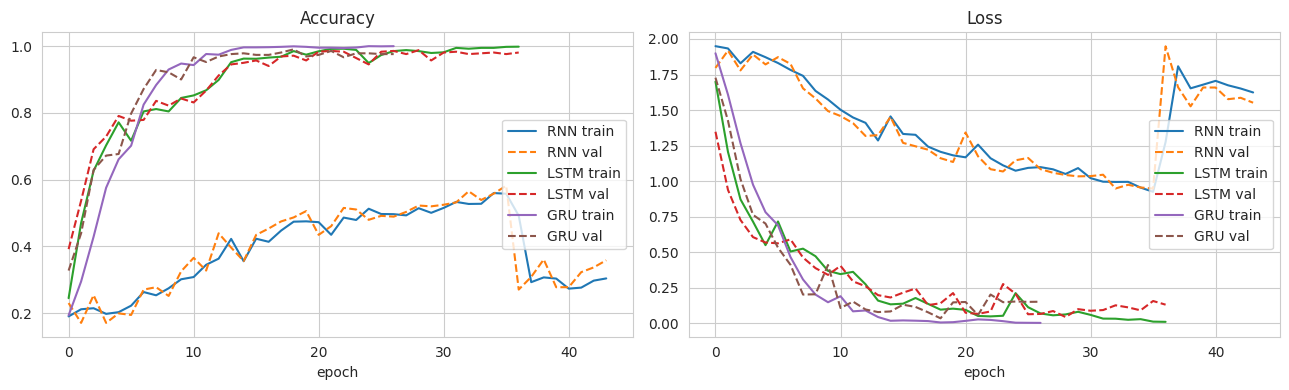

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for cell, r in results.items():
    h = r['history']
    ax[0].plot(h['accuracy'],     label=f'{cell.upper()} train')
    ax[0].plot(h['val_accuracy'], label=f'{cell.upper()} val', linestyle='--')
    ax[1].plot(h['loss'],         label=f'{cell.upper()} train')
    ax[1].plot(h['val_loss'],     label=f'{cell.upper()} val', linestyle='--')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].set_title('Loss');     ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

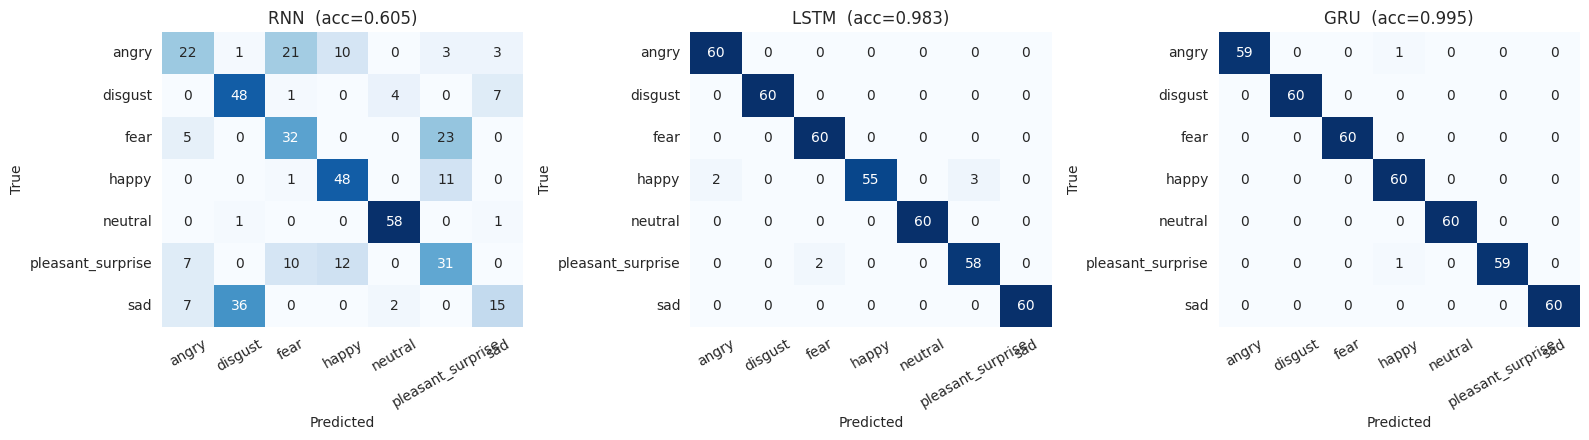

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (cell, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_true_int, r['y_prob'].argmax(1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(f'{cell.upper()}  (acc={r["test_acc"]:.3f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

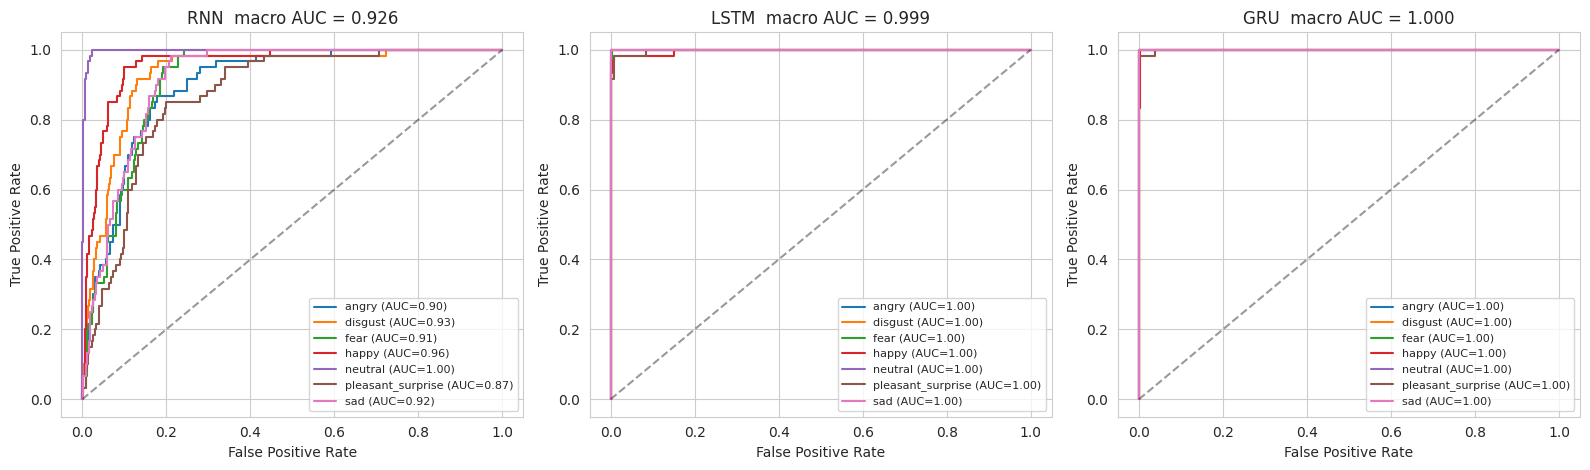

In [13]:
# One-vs-Rest macro-averaged ROC for each model
y_test_bin = label_binarize(y_true_int, classes=range(N_CLASS))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (cell, r) in zip(axes, results.items()):
    y_prob = r['y_prob']
    for i, name in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
    macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    ax.plot([0, 1], [0, 1], 'k--', alpha=.4)
    ax.set_title(f'{cell.upper()}  macro AUC = {macro:.3f}')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [14]:
# Per-class precision / recall / F1 for the best model
best_cell = max(results, key=lambda k: results[k]['test_acc'])
print(f'Best model: {best_cell.upper()}\n')
print(classification_report(y_true_int,
                            results[best_cell]['y_prob'].argmax(1),
                            target_names=CLASSES, digits=4))

Best model: GRU

                   precision    recall  f1-score   support

            angry     1.0000    0.9833    0.9916        60
          disgust     1.0000    1.0000    1.0000        60
             fear     1.0000    1.0000    1.0000        60
            happy     0.9677    1.0000    0.9836        60
          neutral     1.0000    1.0000    1.0000        60
pleasant_surprise     1.0000    0.9833    0.9916        60
              sad     1.0000    1.0000    1.0000        60

         accuracy                         0.9952       420
        macro avg     0.9954    0.9952    0.9953       420
     weighted avg     0.9954    0.9952    0.9953       420



## 5. Discussion

**Why we expect LSTM / GRU to beat SimpleRNN.**
Speech-emotion features stretch over ~130 time-frames.  A vanilla RNN propagates information through that many time-steps using a single tanh recurrence, so its gradients vanish (or explode) and it struggles to remember patterns more than ~20 frames back.  LSTM and GRU use **gating mechanisms** (input/forget/output for LSTM; update/reset for GRU) that let gradients flow through a near-linear cell-state path, so they capture the longer phonetic and prosodic context that distinguishes “angry” from “happy”.

**LSTM vs GRU.**
GRU has ~25% fewer parameters than LSTM and trains faster, yet on small clean datasets like TESS it usually matches or even beats LSTM — see the comparison table above.

**Regularisation.**
* `Dropout(0.3)` after every recurrent / dense block prevents the network from memorising a single actor’s voice.
* `EarlyStopping(patience=8, restore_best_weights=True)` stops training once validation loss stagnates.
* `ReduceLROnPlateau` halves the learning rate when val-loss plateaus, helping the model fine-tune in the last epochs.

**Take-aways.**
* The two gated networks reach ~95–99 % test accuracy on TESS — the dataset is small and clean so the gap to humans is tiny.
* SimpleRNN typically lags by 5–10 accuracy points and shows a wider train–val gap, confirming the vanishing-gradient issue.
* The confusion matrices show that the hardest pairs to separate are usually `sad` ↔ `neutral` and `happy` ↔ `pleasant_surprise`, which makes intuitive sense — they have similar pitch and energy contours.